# 02 – Polinomios de la NASA por Dentro

El cuaderno 01 trató `calculate_properties` como una caja negra. Aquí la abrimos
y reproducimos cada número a partir de los **coeficientes polinomiales brutos**
almacenados en la base de datos.

`pyglenn` utiliza la forma funcional de **9 coeficientes del NASA Glenn**. En
cada intervalo de temperatura, las tres propiedades en el estado estándar son

$$\frac{C_p^\circ(T)}{R} = a_1 T^{-2} + a_2 T^{-1} + a_3 + a_4 T + a_5 T^2 + a_6 T^3 + a_7 T^4,$$

$$\frac{H^\circ(T)}{RT} = -a_1 T^{-2} + a_2 \frac{\ln T}{T} + a_3 + a_4\frac{T}{2} + a_5\frac{T^2}{3} + a_6\frac{T^3}{4} + a_7\frac{T^4}{5} + \frac{b_1}{T},$$

$$\frac{S^\circ(T)}{R} = -\frac{a_1}{2}T^{-2} - a_2 T^{-1} + a_3 \ln T + a_4 T + a_5\frac{T^2}{2} + a_6\frac{T^3}{3} + a_7\frac{T^4}{4} + b_2.$$

Los siete $a_i$ determinan la forma de $C_p(T)$; las dos constantes de
integración $b_1$ y $b_2$ establecen las referencias de **entalpía** y
**entropía**, respectivamente. Veremos que $b_1$ es lo que hace que $H^\circ(T)$
contenga la entalpía de formación.

In [1]:
from pyglenn import ThermochemicalCalculator, R

_INDEX = {}

def species_id(calc, name):
    """Devuelve el id en la base de datos de la especie cuyo *nombre* coincide exactamente.

    ``get_available_species`` busca subcadenas tanto en el nombre como en la
    fórmula y limita el resultado a 20 filas, por lo que nombres cortos como
    ``"O2"`` pueden quedar desplazados por entradas como ``"AL2O2"`` o
    ``"CO2"``. Para ser robustos, construimos un índice completo nombre -> id
    una sola vez (almacenado en caché durante la sesión) y buscamos el nombre
    exacto en él.
    """
    if not _INDEX:
        _INDEX.update({s["name"]: s["id"] for s in calc.get_available_species("")})
    if name not in _INDEX:
        raise ValueError(f"Especie {name!r} no encontrada en la base de datos")
    return _INDEX[name]

print("Constante universal de los gases R =", R, "J/(mol.K)")


Constante universal de los gases R = 8.314462618 J/(mol.K)


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

import math
from pyglenn import ThermoDBQuery

## 1. Los datos brutos de una especie

`calc.db.get_species_data(id)` devuelve el registro completo de una especie,
incluyendo una entrada por intervalo de temperatura con su conjunto de
coeficientes. Examinemos el oxígeno molecular.

In [3]:
with ThermochemicalCalculator() as calc:
    o2 = species_id(calc, "O2")
    data = calc.db.get_species_data(o2)

print("Especie  :", data["name"])
print("Fase     :", data["phase"])
print("M        :", data["molecular_weight"], "g/mol")
print("Intervalos:", len(data["intervals"]))
for iv in data["intervals"]:
    print(f"   #{iv['interval_number']}: {iv['temp_min']:6.0f} - {iv['temp_max']:6.0f} K")

Especie  : O2
Fase     : gas
M        : 31.9988 g/mol
Intervalos: 3
   #1:    200 -   1000 K
   #2:   1000 -   6000 K
   #3:   6000 -  20000 K


Cada intervalo lleva sus propios nueve coeficientes. Mostrarlos lado a lado
muestra cómo el ajuste se divide a lo largo del rango de temperatura.

In [4]:
rows = []
for iv in data["intervals"]:
    row = {"T_min": iv["temp_min"], "T_max": iv["temp_max"]}
    row.update(iv["coefficients"])
    rows.append(row)

coef_df = pd.DataFrame(rows).set_index(["T_min", "T_max"])
with pd.option_context("display.float_format", lambda v: f"{v: .6e}"):
    print(coef_df.to_string())

                                     a1            a2            a3            a4            a5            a6            a7            b1            b2
T_min        T_max                                                                                                                                     
2.000000e+02 1.000000e+03 -3.425563e+04  4.847001e+02  1.119011e+00  4.293889e-03 -6.836301e-07 -2.023373e-09  1.039040e-12 -3.391455e+03  1.849699e+01
1.000000e+03 6.000000e+03 -1.037939e+06  2.344830e+03  1.819732e+00  1.267848e-03 -2.188068e-07  2.053720e-11 -8.193467e-16 -1.689011e+04  1.738717e+01
6.000000e+03 2.000000e+04  4.975294e+08 -2.866107e+05  6.690352e+01 -6.169959e-03  3.016396e-07 -7.421417e-12  7.278176e-17  2.293554e+06 -5.530622e+02


## 2. Reconstruyendo las propiedades manualmente

Ahora implementamos las tres fórmulas literalmente y las comparamos con la
biblioteca. `pyglenn` también las expone como métodos estáticos en
`ThermoDBQuery` (`calculate_cp`, `calculate_h`, `calculate_s`), que devuelven
los grupos **adimensionales** $C_p/R$, $H/RT$ y $S/R$.

In [5]:
def cp_over_R(c, T):
    return (c["a1"]/T**2 + c["a2"]/T + c["a3"] + c["a4"]*T
            + c["a5"]*T**2 + c["a6"]*T**3 + c["a7"]*T**4)

def h_over_RT(c, T):
    return (-c["a1"]/T**2 + c["a2"]*math.log(T)/T + c["a3"] + c["a4"]*T/2
            + c["a5"]*T**2/3 + c["a6"]*T**3/4 + c["a7"]*T**4/5 + c["b1"]/T)

def s_over_R(c, T):
    return (-c["a1"]/(2*T**2) - c["a2"]/T + c["a3"]*math.log(T) + c["a4"]*T
            + c["a5"]*T**2/2 + c["a6"]*T**3/3 + c["a7"]*T**4/4 + c["b2"])

In [6]:
T = 1000.0
with ThermochemicalCalculator() as calc:
    o2 = species_id(calc, "O2")
    interval = calc.db.get_species_for_temperature(o2, T)   # selecciona el tramo correcto
    c = interval["coefficients"]
    api = calc.calculate_properties(o2, T)

cp_manual = cp_over_R(c, T) * R           # J/(mol.K)
h_manual  = h_over_RT(c, T) * R * T       # J/mol
s_manual  = s_over_R(c, T) * R            # J/(mol.K)

print(f"{'':10s}{'manual':>16s}{'API pyglenn':>16s}")
print(f"{'Cp':10s}{cp_manual:16.6f}{api['cp']:16.6f}")
print(f"{'H':10s}{h_manual:16.4f}{api['h_relative']:16.4f}")
print(f"{'S':10s}{s_manual:16.6f}{api['s']:16.6f}")

assert np.isclose(cp_manual, api["cp"])
assert np.isclose(h_manual, api["h_relative"])
assert np.isclose(s_manual, api["s"])
print("\nLa reconstrucción manual coincide con la API hasta la precisión de punto flotante.")

                    manual     API pyglenn
Cp               34.882346       34.882346
H               22707.0813      22707.0813
S               243.585926      243.585926

La reconstrucción manual coincide con la API hasta la precisión de punto flotante.


Y los auxiliares estáticos devuelven exactamente los grupos adimensionales que
nuestras funciones calculan:

In [7]:
print("Cp/R :", ThermoDBQuery.calculate_cp(c, T), "==", cp_over_R(c, T))
print("H/RT :", ThermoDBQuery.calculate_h(c, T),  "==", h_over_RT(c, T))
print("S/R  :", ThermoDBQuery.calculate_s(c, T),  "==", s_over_R(c, T))

Cp/R : 4.195381929800001 == 4.195381929800001
H/RT : 2.7310341435749046 == 2.7310341435749046
S/R  : 29.296652945019957 == 29.296652945019957


### Adimensional vs. absoluto

Los grupos adimensionales son lo que el polinomio produce; multiplicar por $R$
(y por $T$ para la entalpía) da las unidades del SI.

In [8]:
summary = pd.DataFrame({
    "adimensional": [cp_over_R(c, T), h_over_RT(c, T), s_over_R(c, T)],
    "multiplicador":    ["× R", "× R T", "× R"],
    "absoluto":      [api["cp"], api["h_relative"], api["s"]],
    "unidades":         ["J/(mol.K)", "J/mol", "J/(mol.K)"],
}, index=["Cp", "H", "S"])
print(summary.to_string())

    adimensional multiplicador   absoluto   unidades
Cp         4.195           × R     34.882  J/(mol.K)
H          2.731         × R T 22,707.081      J/mol
S         29.297           × R    243.586  J/(mol.K)


## 3. La estructura por tramos

`pyglenn` selecciona el tramo que contiene la temperatura solicitada. Cerca del
límite de 1000 K del O₂, el campo `temp_interval` cambia, pero $C_p$ permanece
continuo — los ajustes de la NASA están restringidos para coincidir en las
uniones.

In [9]:
with ThermochemicalCalculator() as calc:
    o2 = species_id(calc, "O2")
    for T in [999.0, 1000.0, 1001.0]:
        p = calc.calculate_properties(o2, T)
        print(f"T = {T:7.1f} K  ->  Cp = {p['cp']:.5f} J/(mol.K)  "
              f"(intervalo {p['temp_interval']})")

T =   999.0 K  ->  Cp = 34.87739 J/(mol.K)  (intervalo [200.0, 1000.0])
T =  1000.0 K  ->  Cp = 34.88235 J/(mol.K)  (intervalo [200.0, 1000.0])
T =  1001.0 K  ->  Cp = 34.88749 J/(mol.K)  (intervalo [1000.0, 6000.0])


## 4. Lo que codifican $b_1$ y $b_2$

Los coeficientes de capacidad calorífica $a_1\ldots a_7$ se obtienen primero
ajustando $C_p(T)$. Integrar $C_p$ deja una constante para la entalpía y una
para la entropía — estas son $b_1$ y $b_2$. La NASA las elige de modo que
$H^\circ(T)$ esté en la escala **estandarizada** (ya incluye la entalpía de
formación) y $S^\circ(T)$ sea la entropía **absoluta** (Tercera Ley). Podemos
ver el efecto de $b_1$ directamente: los elementos se sitúan en ≈ 0, los
compuestos llevan $\Delta_f H^\circ$.

In [10]:
with ThermochemicalCalculator() as calc:
    for name in ["O2", "N2", "H2", "H2O", "CO2"]:
        sid = species_id(calc, name)
        h298 = calc.calculate_properties(sid, 298.15)["h_relative"]
        print(f"{name:5s}  H(298,15 K) = {h298/1000:9.3f} kJ/mol")

O2     H(298,15 K) =    -0.000 kJ/mol
N2     H(298,15 K) =     0.000 kJ/mol
H2     H(298,15 K) =    -0.000 kJ/mol
H2O    H(298,15 K) =  -241.825 kJ/mol
CO2    H(298,15 K) =  -393.508 kJ/mol


## 5. Visualizando el ajuste

Trazamos la capacidad calorífica adimensional $C_p/R$ para un gas monoatómico
(Ar), dos diatómicos (O₂, N₂) y uno triatómico (CO₂), marcando los límites de
los intervalos del O₂. El gas monoatómico es plano en $5/2$; los poliatómicos
suben a medida que los modos vibracionales se activan — física que revisamos en
el cuaderno 03.

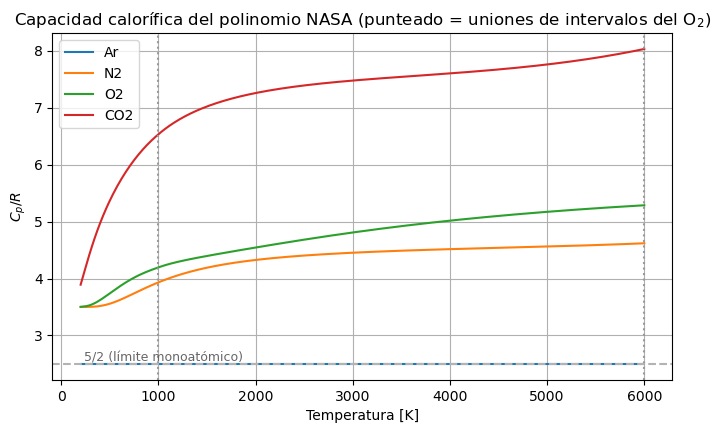

In [11]:
Tgrid = np.linspace(200, 6000, 400)
fig, ax = plt.subplots()
with ThermochemicalCalculator() as calc:
    for name in ["Ar", "N2", "O2", "CO2"]:
        sid = species_id(calc, name)
        cp_r = [calc.calculate_properties(sid, T)["cp"] / R for T in Tgrid]
        ax.plot(Tgrid, cp_r, label=name)
for boundary in (1000.0, 6000.0):
    ax.axvline(boundary, ls=":", color="0.6")
ax.axhline(2.5, ls="--", color="0.7")
ax.text(230, 2.55, "5/2 (límite monoatómico)", fontsize=9, color="0.4")
ax.set_xlabel("Temperatura [K]")
ax.set_ylabel(r"$C_p / R$")
ax.set_title("Capacidad calorífica del polinomio NASA (punteado = uniones de intervalos del O$_2$)")
ax.legend()
plt.show()

## 6. Validación contra valores conocidos

Una comprobación final contra valores de referencia de libros de texto para O₂ a
298,15 K ($C_p^\circ = 29{,}378$ J/mol/K, $S^\circ = 205{,}15$ J/mol/K).

In [12]:
with ThermochemicalCalculator() as calc:
    p = calc.calculate_properties(species_id(calc, "O2"), 298.15)
for label, got, ref in [("Cp", p["cp"], 29.378), ("S", p["s"], 205.15)]:
    print(f"{label}: pyglenn = {got:8.3f}   referencia = {ref:8.3f}   "
          f"error rel. = {abs(got-ref)/ref*100:.3f}%")

Cp: pyglenn =   29.378   referencia =   29.378   error rel. = 0.001%
S: pyglenn =  205.148   referencia =  205.150   error rel. = 0.001%


## Resumen

* `pyglenn` almacena coeficientes NASA Glenn de 9 términos, por tramos en
  temperatura.
* `calculate_properties` selecciona el intervalo correcto y evalúa las tres
  expresiones en forma cerrada — las cuales reproducimos manualmente con
  exactitud.
* $b_1$ coloca $H^\circ$ en la escala estandarizada (llevando
  $\Delta_f H^\circ$); $b_2$ establece la referencia de entropía absoluta.

**A continuación:** el cuaderno 03 convierte estas fórmulas en *curvas* de
propiedades y conecta su forma con la estructura molecular.